┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; interpreting Array{Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136}} as Array{Any}
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\datasets.jl:128
┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:574
┌ Warning: type Main.#rho#136 does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:458
┌ Warning: type SuiteSparseGraphBLAS.GBMatrix{Float64,Float64} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:574
┌ Warning: type Base.RefValue{Ptr{SuiteSparseGraphBLAS.LibGraphBLAS.GB_Matrix_opaque}} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\k

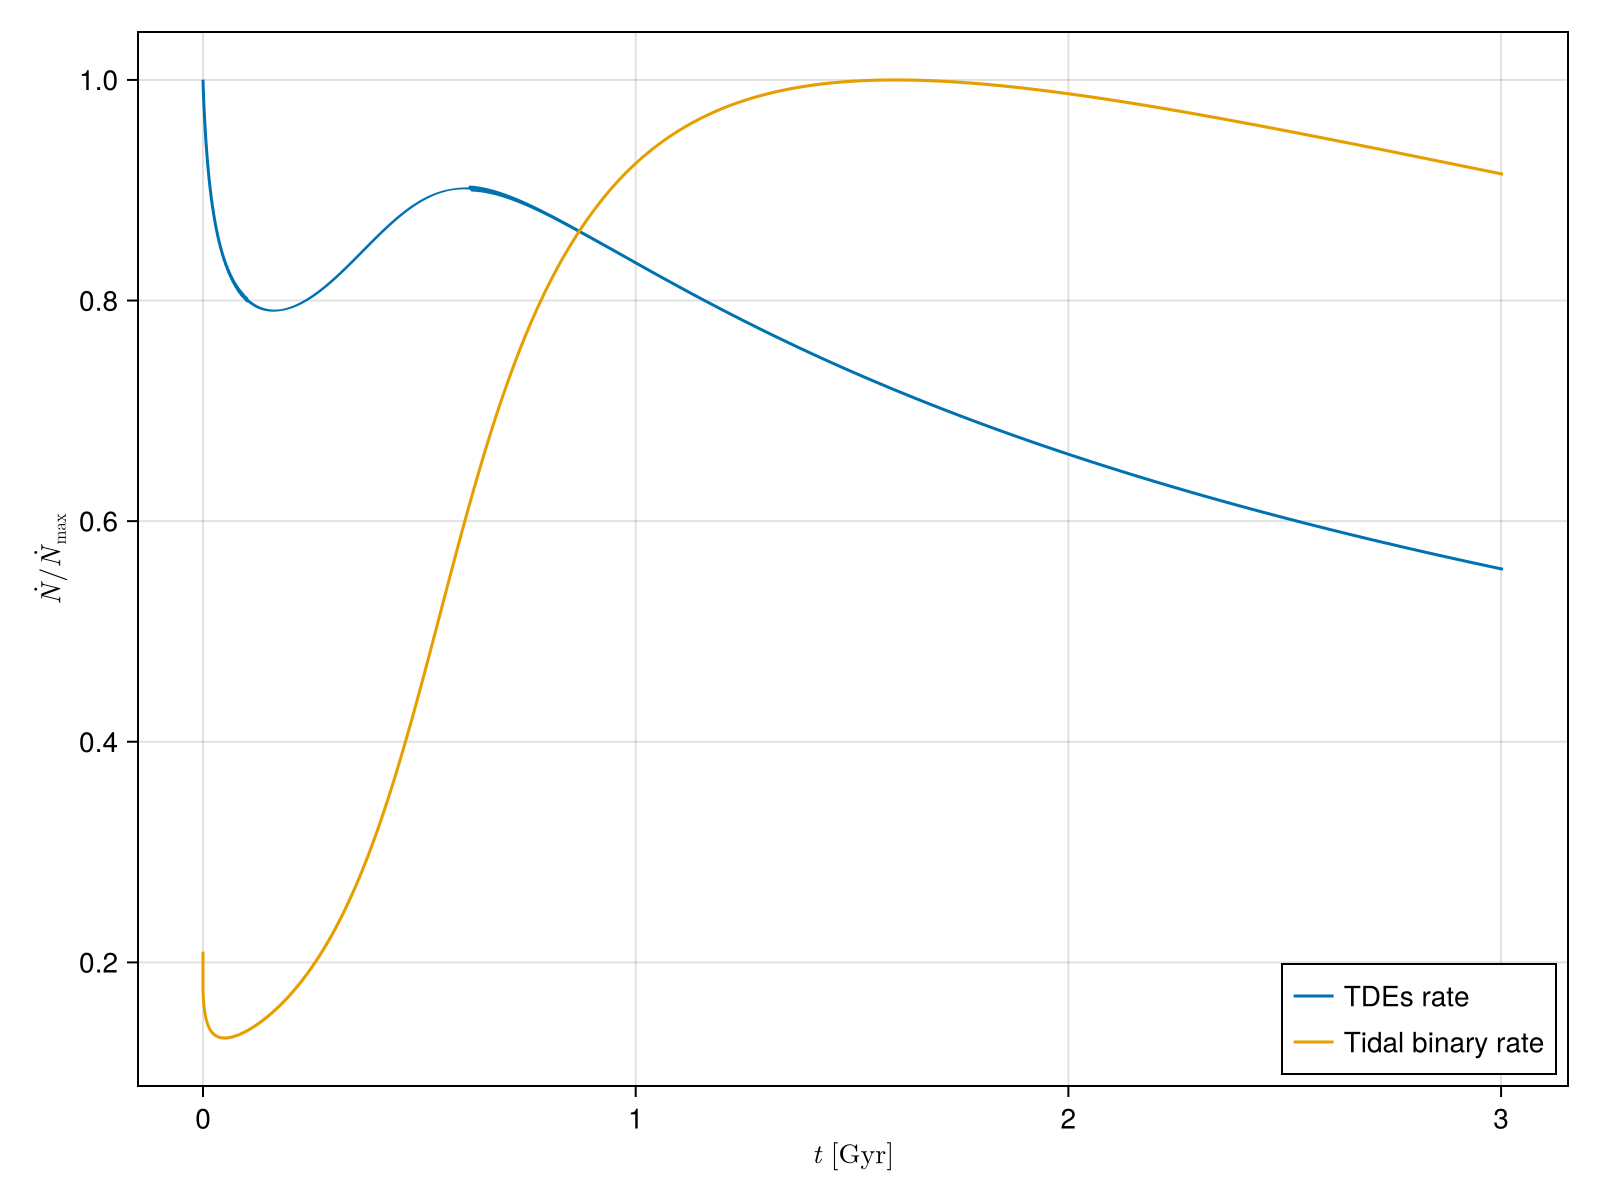

Insert the time t1 in Gyr:


stdin>  1


Insert the time t2 in Gyr:


stdin>  1.5


In [1]:
# Lets obtain the orbitas propiertes of the disrupted sBHBs center of mass

using JLD2, FileIO
using CairoMakie
using Printf
using Makie
using Dierckx
using Glob
using SpecialFunctions
using LinearAlgebra
using Distributions

final_output = load("C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/summary_2_4.0e6_4.8e-7_100x100.jld2")
params = final_output["params"]
aux = final_output["aux"]

time = final_output["t"]/params["Gyr"]
TDE_rate = final_output["captures"][1] * params["Gyr"] * 1e-9 #rates in 1/yr
TDE_binary = final_output["captures"][2] * params["Gyr"] * 1e-9 #rates in 1/yr

TDE_norm=TDE_rate/maximum(TDE_rate) #normalize rates
TDE_binary_norm=TDE_binary/maximum(TDE_binary) #normalize rates

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xlabel=L"$t$ [Gyr]", ylabel=L"\dot{N} / \dot{N}_{\max}")

lines!(ax, time, TDE_norm, label="TDEs rate")
lines!(ax, time, TDE_binary_norm, label="Tidal binary rate")

axislegend(ax, position=:rb)

display(fig)

function trapz(x, y)
    sum( 0.5 * (y[1:end-1] .+ y[2:end]) .* diff(x) )
end

t=[]
folder = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_$(params["M"])_4.8e-7"
basename_prefix = "snap_grid_$(length(aux["R_val"]))x$(length(aux["s_val"]))_"
files = glob(basename_prefix * "*", folder)

indices_snapshot = 1:length(files)-1 #explore how many snapshot there are

for i in indices_snapshot
    push!(t,time[i*40])
end

t_new=vcat(0,t)

println("Insert the time t1 in Gyr:")
t1 = parse(Float64, readline())
println("Insert the time t2 in Gyr:")
t2 = parse(Float64, readline())
max_ind = findall(x -> t1 <= x <= t2, t)

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xlabel=L"$t$ [Gyr]", ylabel=L"\dot{N}\ [1/yr] ")

lines!(ax, time, TDE_binary, label="TDEs binary")

vlines!(ax, [t1, t2], color=:red, linewidth=2, linestyle=:dash)

axislegend(ax, position=:rb)

save("Selected timespan $(params["M"])_0.1AU.pdf", fig)

E = params["E0"] * (exp.(aux["s_val"]) .- 1.0)

function besseli_leo(x,y)
    return besseli(0, x)./besseli(1, y)
end

q_t=[]
f_t=[]
dN_dEdt=[]

for i in max_ind
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_$(params["M"])_4.8e-7/snap_grid_$(length(aux["R_val"]))x$(length(aux["s_val"]))_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    push!(dN_dEdt,snap["diff_rate"][2] * params["Gyr"])
    push!(q_t, snap["q"][2])
    push!(f_t, snap["f_e"][2])
end

dN_dEdt = Matrix(reduce(hcat, dN_dEdt)')
q_t = Matrix(reduce(hcat, q_t)')


N_E = length(E)
r_LC = final_output["params"]["rlc"][2]

N_rp = 100
r_p = range(0, r_LC; length=N_rp)
dx = step(r_p)

dNdrpdEdt = zeros(N_E, length(max_ind), N_rp)
dN_dEdt_2=dN_dEdt*0.0

for i in 1:N_E
    q = q_t[:,i]
    f = [ f_t[j][aux["Rlc_idx"][2][i], i] for j in 1:length(max_ind)]
    dNdrp_matrix = zeros(length(max_ind), length(r_p))
    for j in 1:length(max_ind) 
        dN_dEdt_2[:,i]=4*pi^2*aux["l2c"][i]*q.*(q.^2+q.^4).^-0.25 .* f
        arg = @. 2 * sqrt.(r_p ./ (q[j] * r_LC))
        norm = 2 / sqrt(q[j])
        if q[j] < 0.01
            dN_drp = zeros(length(r_p))
            x0 = r_LC
            ix = findall(abs.(r_p .- x0) .< dx/2)
            dN_drp[ix] .= 1 / dx
        elseif q[j] > 10
            dN_drp = fill(1/r_LC, length(r_p))
        else
            dN_drp = (1/(r_LC*sqrt(q[j]))) .* @.besseli_leo(arg, norm)
        end
        dNdrp_matrix[j, :] .= dN_drp
    end
    dNdrpdEdt[i, :, :] = dN_dEdt_2[:,i] .* dNdrp_matrix
    
end

dNdrpdE = [trapz(t_new[max_ind], dNdrpdEdt[i, :, j]) for i in 1:length(E), j in 1:length(r_p)]

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], xlabel=L"Specific\ energy\ in\ internal\ units", ylabel=L"r_{p}/r_{lc}", limits=(-200,10,nothing,nothing), title="Distribution of E and rₚ between t = $t1 and t = $t2 Gyr")
hm = heatmap!(ax, -(E.-params["phis0"]), r_p/r_LC, dNdrpdE; colormap=:viridis, colorrange=(0, 0.5*maximum(dNdrpdE)))
Colorbar(fig[1,2], hm,  label = L"\frac{dN}{dE \, dr_p}")

dt = diff(t_new*1e9)
sub_TDE_binary=TDE_binary[1:40:end]
lambas=sub_TDE_binary[1:length(files)-1].*dt
lamba2=trapz(t_new[max_ind],sub_TDE_binary[max_ind])
e_for_plot=[]
e_for_plot2=[]
E_for_plot=[]
L_for_plot=[]
B_for_plot=[]
E_MBH=[]
a_for_plot=[]
q_for_plot=[]
EMRIs_time=[]

for p in 1:1
	realizations= 1:1
	TDE_final=[]
	for j in realizations
		Total_TDE=[]
		for i in lambas
			y=rand(Poisson(i))
			push!(Total_TDE,y)
		end
		push!(TDE_final,Total_TDE[max_ind])
	end

	snap1=[]
	time_snap=[]
		
	for i in 1:length(max_ind)
		if TDE_final[1][i]!=0
			for j in 1:TDE_final[1][i]
				push!(snap1, max_ind[i])
				push!(time_snap, t_new[max_ind[i]])
			end
		end
	end

    push!(EMRIs_time, time_snap)
    
	using Random, Interpolations

	GMsun_km = 1.3271244e11       # km^3/s^2,
	AU_in_km = 1.495978707e8      # km to AU
	N_events=sum(TDE_final[1])

	accepted_energies_final=[]
	for j in realizations
		accepted_energies = []
		for i in 1:length(max_ind)
			itp = interpolate((E,), dN_dEdt_2[i,:], Gridded(Linear()))
			
			p_max = maximum(dN_dEdt_2[i,:])
		
			N_TDE = TDE_final[j][i]
		
			E_min = minimum(E)
			E_max = maximum(E)
		
			Ei = Float64[]
			
			while length(Ei) < N_TDE
				E_trial = rand() * (E_max - E_min) + E_min
				y = rand() * p_max
				if y < itp(E_trial)
					push!(Ei, E_trial)
				end
			end
		
			push!(accepted_energies, Ei)
		end
		push!(accepted_energies_final, accepted_energies)
	end

	acepted_rp_total=[]
	acepted_B_total=[]
	q_out=[]
	
	for k in realizations
		accepted_rp = []
		accepted_B = []
		for i in max_ind
			snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_$(params["M"])_4.8e-7/snap_grid_$(length(aux["R_val"]))x$(length(aux["s_val"]))_$(@sprintf("%03d", i)).jld2"
			snap = load(snapshot_file)
			energies = accepted_energies_final[k][i-minimum(max_ind)+1]
			q_E = snap["q"][2]
			itp_qE = interpolate((E,), q_E, Gridded(Linear()))
			rp= Float64[]
			B= Float64[]
			for j in energies
				q=itp_qE(j)
				push!(q_out, q)
				arg = @. 2 * sqrt.(r_p ./ (q * r_LC))
				norm = 2 / sqrt(q)
				if q < 0.01
					push!(rp,r_LC)
					push!(B, 1)
				elseif q > 10
					push!(rp, rand() * r_LC)
					push!(B, r_LC / (rand() * r_LC))
				else
					dN_drp = (1/(r_LC*sqrt(q))) .* @.besseli_leo(arg, norm)
					while true  
						itp_rp = interpolate((collect(r_p),), dN_drp, Gridded(Linear()))
						rp_trial = rand() * r_LC
						p_max = maximum(dN_drp)
						y = rand() * p_max          
						if y < itp_rp(rp_trial)
							push!(rp, rp_trial)
							push!(B, r_LC/rp_trial)
							break
						end
					end
				end
			end
			push!(accepted_rp,rp)
			push!(accepted_B,B)
		end
		push!(acepted_rp_total, accepted_rp)
		push!(acepted_B_total, accepted_B)
	end

	Specific_energies=vcat(vcat(accepted_energies_final...)...)*(params["sigma"]*(params["v_u"])/1000)^2
	push!(E_for_plot, Specific_energies)
	Specific_energies_2 = -(Specific_energies.-params["phis0"]*(params["sigma"]*(params["v_u"])/1000)^2)
    push!(E_MBH, Specific_energies_2)
	Beta=vcat(vcat(acepted_B_total...)...)
	push!(B_for_plot,Beta)
    push!(q_for_plot, q_out)
	# @infiltrate
	a_km = - (GMsun_km * params["M"]) / (2 * Specific_energies_2)

	a_au = a_km / AU_in_km

	push!(a_for_plot, a_au)
    
	L_out=[]
	rLC_km = r_LC * params["r_u"] / 1000.0
	for i in 1:length(Beta)
		L= (2 * (rLC_km/Beta[i])^2 * ( GMsun_km * params["M"] / (rLC_km/Beta[i]) - Specific_energies_2[i]))^(1/2)
		push!(L_out, L)
	end
	
	push!(L_for_plot, L_out)

	e=[]
	# @infiltrate
	
	for i in 1:length(a_km)
		# if a_au[i]<0
		# 	e_i=1+(r_LC/Beta[i])/(abs(a_au[i]))
		# 	push!(e,e_i)
		# else
			e_i=1-rLC_km/Beta[i]/a_km[i]
			push!(e,e_i)
		# end
	end
	# e2= sqrt.(1.0 .+ 2*Specific_energies_2 .* L_out.^2 / (GMsun_km * params["M"])^2)
	e2= Specific_energies_2 .* L_out.^2 / (GMsun_km * params["M"])^2
	
	push!(e_for_plot, e)
	push!(e_for_plot2, e2)
	
	filename = "$(params["M"])_0.1AU_$(p)_" * @sprintf("t1_%.3f_t2_%.3f_data_summary.txt", t1, t2)

	open(filename, "w") do io	
		@printf(io, "Number of events between t = %.4f and %.4f Gyr: %d\n", t1, t2, N_events)
		@printf(io, "Method used: Explore snapshot by snapshot \n")
		@printf(io, "Mass of the MBH: %.2e solar masses\n\n", params["M"])
		@printf(io, "The stellar potential is: %.2e [km/s]^2 \n\n", params["phis0"]*(params["sigma"]*(params["v_u"])/1000)^2 )
		
		@printf(io, "%-25s %-15s %-15s %-15s %-10s %-15s %-15s\n", "Total energy [(km/s)^2]", "Specific energy MBH", "Beta", "L [(km^2/s)]", "q", "Snapshot", "Snapshot time [Gyr]")
		@printf(io, "%s\n", "-"^115)

		for (e_val, e_MBH, b, R, q, snap_val, t_snap) in zip(Specific_energies, Specific_energies_2, Beta, L_out, q_out, snap1, time_snap)
			@printf(io, "%-25.5e %-15.5e %-15.5e %-15.5e %-10.5f %-15d %-15.5f\n", e_val, e_MBH, b, R, q, snap_val, t_snap)
		end
	end
end
		
B_for_plot=reduce(vcat, B_for_plot)
E_MBH=reduce(vcat, E_MBH)

fig = Figure()
e_for_plot=reduce(vcat, e_for_plot)
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"1-e", title="Just a prove",   xscale = log10)
CairoMakie.scatter!(ax, B_for_plot, -e_for_plot.+1, markersize=5, color=:red)
save("e_dist_prove.pdf", fig)

fig = Figure()
ome2_for_plot=reduce(vcat, e_for_plot2)
ome_for_plot = 1.0 .- sqrt.(ome2_for_plot .+ 1.0)
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"1-e", title="Just a prove",   xscale = log10)
CairoMakie.scatter!(ax, B_for_plot, ome_for_plot, markersize=5, color=:red)
save("e_new_dist_prove.pdf", fig)

fig = Figure()
E_for_plot = reduce(vcat, E_for_plot) 
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"Specific total energy [Km/s]^2", title="Just a prove",   xscale = log10, limits = (1, 100, nothing, nothing))
CairoMakie.scatter!(ax, B_for_plot, E_for_plot, markersize=5, color=:red)
CairoMakie.hlines!(params["phis0"]*(params["sigma"]*(params["v_u"])/1000)^2, linestyle=:dash)
save("E_dist.pdf", fig)

fig = Figure()
L_for_plot = reduce(vcat, L_for_plot) 
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"Specific angular momentum [km^2/s]", title="Just a prove",   xscale = log10, yscale=log10, limits = (1, 100, nothing, nothing))
CairoMakie.scatter!(ax, B_for_plot, L_for_plot, markersize=5, color=:red)
save("L_dist.pdf", fig)

a_for_plot=v = collect(transpose(a_for_plot)) 
fig = Figure()
a_for_plot = reduce(vcat, a_for_plot) 
ax = Axis(fig[1,1], xlabel=L"a (AU)", ylabel=L"e", title="Just a prove")
CairoMakie.scatter!(ax, a_for_plot, sqrt.(ome2_for_plot .+ 1.0), markersize=5, color=:red)
save("e vs a.pdf", fig)

EMRIs_time = reduce(vcat, EMRIs_time)
q_for_plot = reduce(vcat, q_for_plot) 
Beta=B_for_plot
a=a_for_plot;

In [2]:
#e vs Beta

fig = Figure()
ome2_for_plot=reduce(vcat, e_for_plot2)
ome_for_plot = 1.0 .- sqrt.(ome2_for_plot .+ 1.0)
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"1-e", title="Just a prove", limits = (0, 2, -0.0003, 0.001))
sc = CairoMakie.scatter!(
    ax, 
    log10.(B_for_plot), 
    ome_for_plot,
    markersize = 5,
    color = log10.(Float64.(q_for_plot)),  
    colormap = :viridis, 
    colorrange = (-6, 2) 
)

Colorbar(fig[1,2], sc, label = L"q" )

save("e_new_dist_prove.pdf", fig)


CairoMakie.Screen{PDF}


In [3]:
#e vs beta as a function of the loss cone regime

fig = Figure()

ax = Axis(fig[1,1],
    xlabel = L"Beta",
    ylabel = L"1-e",
    title  = "Just a prove",
    limits = (0, 2, -0.0003, 0.001)
)

mask_ELC = q_for_plot .< 0.01    
mask_noELC = .!mask_ELC       

sc1 = CairoMakie.scatter!(
    ax,
    log10.(B_for_plot[mask_ELC]),
    ome_for_plot[mask_ELC],
    markersize = 5,
    color = :blue,
    label = "ELC (< 0.01)"
)

sc2 = CairoMakie.scatter!(
    ax,
    log10.(B_for_plot[mask_noELC]),
    ome_for_plot[mask_noELC],
    markersize = 5,
    color = :red,
    label = "No ELC (≥ 0.01)"
)

Legend(fig[1,2], ax)

save("e_new_LCR.pdf", fig)

CairoMakie.Screen{PDF}


In [4]:
#Distribution of beta and energy for disrupted sBHBs

fig = Figure()
ax = Axis(fig[1,1],
    xlabel = L"\beta",
    ylabel = L"Specific\ Energy\ [\mathrm{km^2\ s^{-2}}]",
    title = "Improving the heat map",
    xscale = log10
)
sc = CairoMakie.scatter!(
    ax,  
    Beta,
    E_MBH,
    markersize = 5,
    color = log10.(Float64.(q_for_plot)),
    colormap = :viridis, 
    colorrange = (-6, 2) 
)

Colorbar(fig[1,2], sc, label = L"q" )

save("Heat_map_better.pdf", fig)


CairoMakie.Screen{PDF}


In [4]:
#trying to get the line t_gw = t_rlx

t_scatter_R = (aux["R_val"].^2 ./ (aux["DRR"] .* params["Gyr"])) .* aux["C"]
t_scatter_R[isnan.(t_scatter_R)] .= 0 
t_scatter_R;

In [5]:
#ok tGW 
#c=3.066e5 #pc Gyr-1
#G=4.49e-12 #pc3 solar -1 Gyr-1
G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 299792458.0          # m/s
Msun = 1.989e30          # kg
pc = 3.085677581e16      # m
seconds_in_Gyr = 3.1536e16  # s
M = 4.3e6 * Msun         
m = 10 * Msun
a = 10 .^ range(-5.4, 0; length=1000) #pc
R = range(0.005, 0.995; length=1000)
R_col = reshape(R, :, 1)
a_row = reshape(a, 1, :)
a_new = a_row .* pc       

function tGW(a, R)
    return ((15/304) * (c^5 .* a.^4 )./ (G^3 * M * m * (M + m)) .* ((1 .- sqrt.(1 .- R)) .*  (R .^(5/2)))./(sqrt.(1 .- R)) .* (1+ (121/304).*(-R.+1)).^(-1))
end                                                                                               

tGW_matrix = (tGW.(a_new, R_col)) ./ seconds_in_Gyr ;

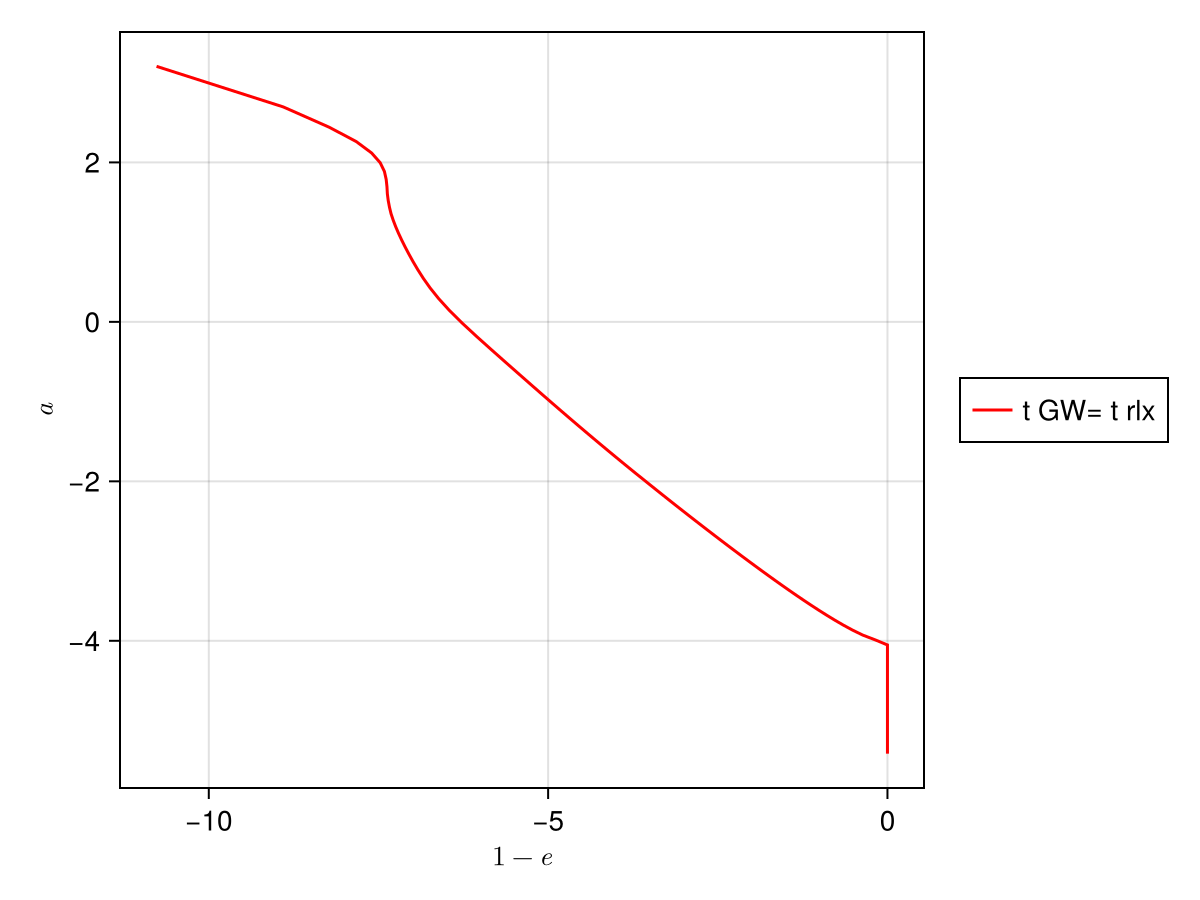

CairoMakie.Screen{IMAGE}


In [6]:
R_eq=[]
for a in eachindex(aux["rc"])
    validindex=aux["R_val"].>aux["Rlc"][2][a]
    if any(validindex)
        itp_rlx=linear_interpolation(log10.(aux["R_val"][validindex]), log10.(t_scatter_R[validindex,a]), extrapolation_bc=Line())
        trlx(R)=exp10(itp_rlx(log10(R)))
#trlx = trlc^LC * R/Rlc, can be writting
#tGW = tGW^LC * (R/RLC)^3.5 scalings for very eccentric orbits 
# (R/RLC) = (trlx^LC/tGW^LC)^(2/5)
# R_tgwtrlx = RLC * (trlx^LC/tGW^LC)^(2/5) #valuo of R when both are equal , inside the loop.
        trlx_lc=trlx(aux["Rlc"][2][a])
        tGW_lc=tGW(aux["rc"][a]*pc, aux["Rlc"][2][a])/seconds_in_Gyr
        push!(R_eq, min((aux["Rlc"][2][a]*(trlx_lc/tGW_lc)^(2/5)),1))
    else 
        push!(R_eq, 1)
    end
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"1-e", ylabel=L"a")
lines!(ax, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:red, label="t GW= t rlx")
Legend(fig[1, 2], ax)
display(fig)
#we get t_gw = t_rlx

In [24]:
#open beta filtered by % in a original simulation, this is done by first extracting beta from the txt file and usin the 5th oder fit.
#ext step, extrat not only beta filtered but als the time at which hapepnds so you have and idea of how many Bhs actually are deposit per time/
using XLSX

data = DataFrame(XLSX.readtable("beta_filtrado.xlsx", "Sheet1")...)

first(data, 5)

Beta = data.beta_filtrado |> collect;

In [18]:
#getting the depostid BHs propiertes

using CSV, DataFrames, StatsBase, Distributions
using CategoricalArrays

df = CSV.read("fractions_data_E0.csv", DataFrame)
n_bins = 200
beta_vals = df.beta_0
edges = range(minimum(beta_vals), stop=maximum(beta_vals), length=n_bins+1)
bin_centers = [0.5*(edges[i] + edges[i+1]) for i in 1:n_bins]

beta_filt = filter(x -> 1 <= x <= maximum(beta_vals), Beta);

In [19]:
bin_cats_filt = cut(beta_filt, edges; extend=true)
bin_indices_filt = bin_cats_filt.refs

counts_per_bin = countmap(bin_indices_filt) 

bin_counts = [get(counts_per_bin, i, 0) for i in 1:n_bins] ;

In [23]:
bin_counts

200-element Vector{Int64}:
 82
 35
 32
 20
 17
 21
 12
 14
 15
 13
 14
  8
  5
  ⋮
  0
  0
  0
  0
  0
  0
  0
  0
  0
  0
  0
  0

In [11]:
using KernelDensity

df_2 = CSV.read("M4e6_E0.csv", DataFrame)

sampled_a = Float64[]
sampled_e = Float64[]

for i in 1:n_bins
    beta_min = edges[i]
    beta_max = edges[i+1]
    n_events = bin_counts[i]

    bin_data = filter(row -> beta_min ≤ row.beta_0 < beta_max, df_2)

    if n_events > 0
        x = bin_data.a_cap
        y = bin_data.e_cap
        points = hcat(x, y)
        
        # KDE 2D
        kde_0 = kde(points)

        for j in 1:n_events
            accepted = false
            while !accepted
                a_try = rand(Uniform(minimum(x), maximum(x)))
                e_try = rand(Uniform(minimum(y), maximum(y)))
                p = pdf(kde_0, a_try, e_try)

                p_max = maximum(kde_0.density)
                if rand() < p / p_max
                    push!(sampled_a, a_try)
                    push!(sampled_e, e_try)
                    accepted = true
                end
            end
        end
    end
end

@show length(sampled_a)
@show length(sampled_e)

length(sampled_a) = 700
length(sampled_e) = 700


700

In [10]:
#the loss cone for the remains BH

x_vals = range(-4, 0, length=200)
const_val = log10((8 * G * M / c^2)*3.24e-17) 
y_vals = .-x_vals .+ const_val;

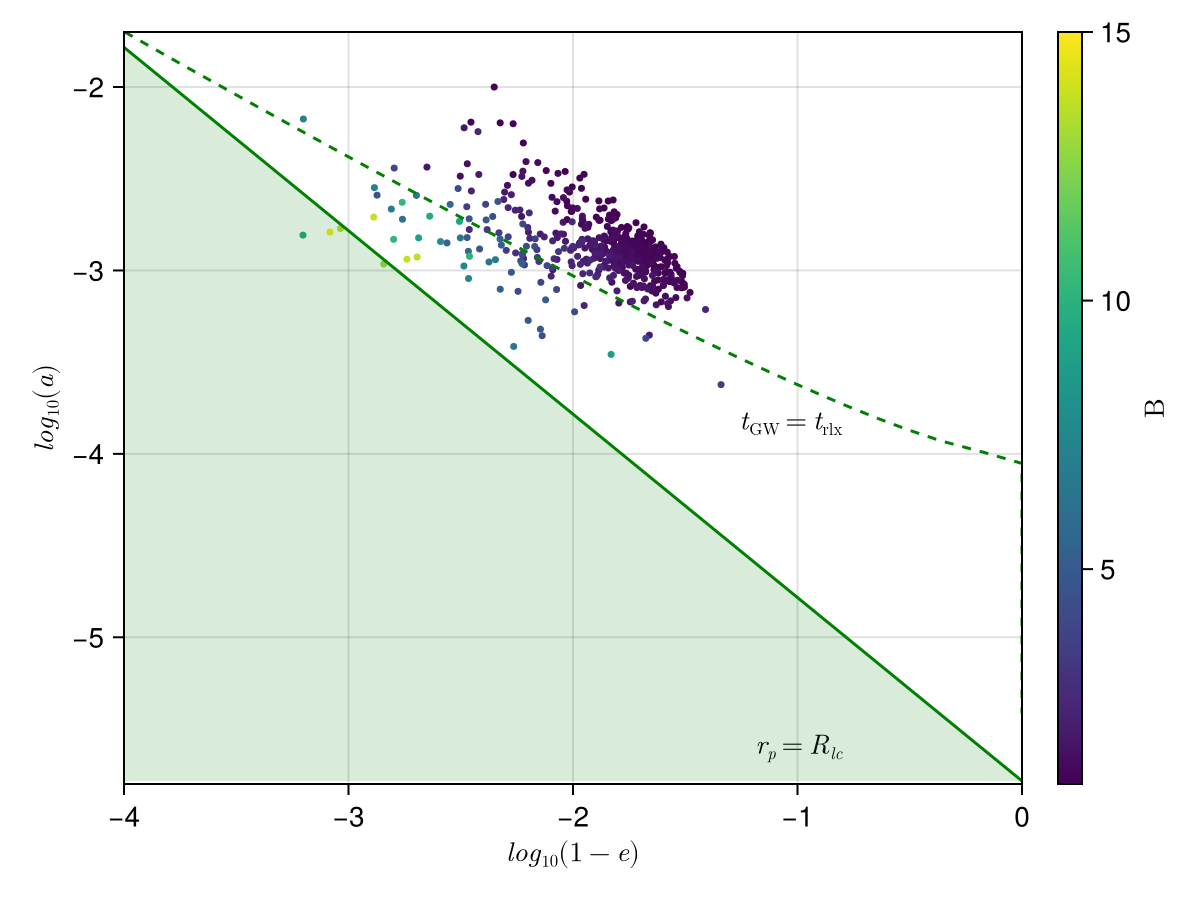

CairoMakie.Screen{PDF}


In [11]:
colors_labels = Float64[]
for (cant, val) in zip(bin_counts, bin_centers)
    append!(colors_labels, fill(val, cant))
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)")
sc=scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
text!(ax, [maximum(log10.(-sqrt.(-R_eq.+1).+1)) - 0.8], [log10.(aux["rc"])[end] + 1.5], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)
display(fig)

save("Remaining BHs.pdf", fig)
#evolving with rp = cts paralel to the LC , simulation of peter eq.
#do it with a bulk around -2

In [12]:
# just curoisity, how many points are inside , how many are outside
using Logging

global_logger(ConsoleLogger(stderr, Logging.Error))

x_line = log10.(-sqrt.(-R_eq.+1).+1)
y_line = log10.(aux["rc"])

x_line = collect(x_line)
y_line = collect(y_line)

x_pts = log10.(-sampled_e .+ 1)
y_pts = log10.(sampled_a)

itp = LinearInterpolation(x_line, y_line, extrapolation_bc=Flat())

y_on_line = itp.(x_pts)

n_inside = sum(y_pts .<= y_on_line) 
n_outside = sum(y_pts .> y_on_line)

println("deposit BHs inside the GW domain: $n_inside")
println("deposit BHs outside the GW domain: $n_outside")

Puntos dentro de la línea: 62
Puntos fuera de la línea: 447


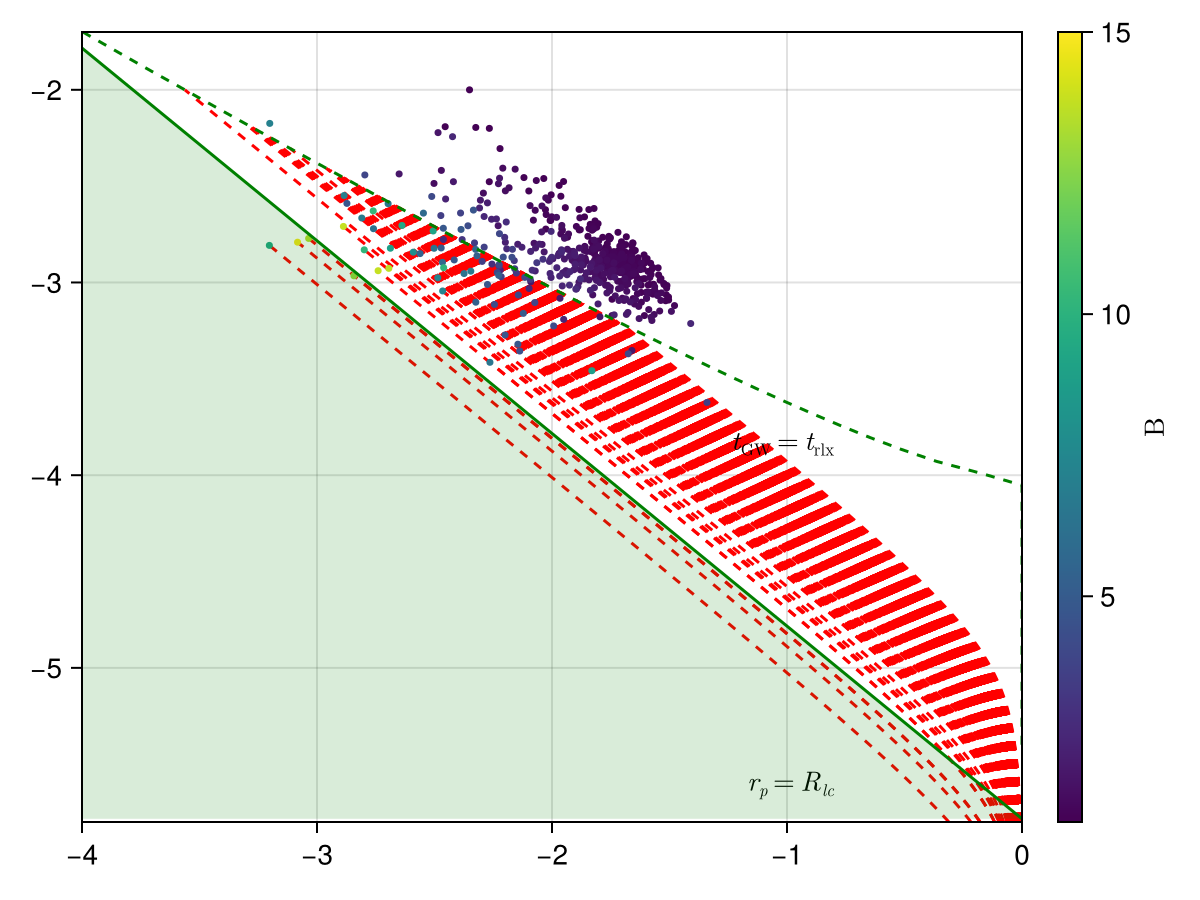

CairoMakie.Screen{IMAGE}


In [13]:
#time to evolving..until eRO-QPE 2

inside_mask = y_pts .<= y_on_line
outside_mask = .!inside_mask

# Puntos dentro
x_inside = x_pts[inside_mask]
y_inside = y_pts[inside_mask]

# Puntos fuera proyectados horizontalmente
x_outside_proj = similar(x_pts[outside_mask])
y_outside_proj = y_pts[outside_mask]  # a fijo

sorted_idx = sortperm(y_line)
y_line_sorted = y_line[sorted_idx]
x_line_sorted = x_line[sorted_idx]

for (i, a_val) in enumerate(y_outside_proj)

    itp_inv = LinearInterpolation(y_line_sorted, x_line_sorted, extrapolation_bc=Flat())
    x_outside_proj[i] = itp_inv(a_val)
end

x_evol_init = vcat(x_inside, x_outside_proj)
y_evol_init = vcat(y_inside, y_outside_proj)

e_init = 1 .- 10 .^ x_evol_init
a_init = 10 .^ y_evol_init

function a_peters(e, c0)
    return c0 * (e.^(12/19)) ./ (1 .- e.^2) .* (1 .+ 121/304 .* e.^2).^(870/2299)
end

const C = 2.88e-8
M = 4e6
resultado = C * (M / 1)^(1/3) 

a_target = 5.15e-6
e_at_a_target = Float64[]
log_a_target = log10.(a_target)

fig = Figure()
ax = Axis(fig[1,1])

function obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    log_a_vals = log10.(a_vals)
    if minimum(log_a_vals) > log_a_target
        return missing 
    end
    interp_e = linear_interpolation(log_a_vals, e_vals, extrapolation_bc=Line())
    return interp_e(log_a_target)
end

first=true
for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target, e_at_log_a_p)

    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)
    if first
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5, label="Peters evolution")
        first = false
    else
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5)
    end
end

sc=scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
text!(ax, [maximum(log10.(-sqrt.(-R_eq.+1).+1)) - 0.8], [log10.(aux["rc"])[end] + 1.5], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)

display(fig)

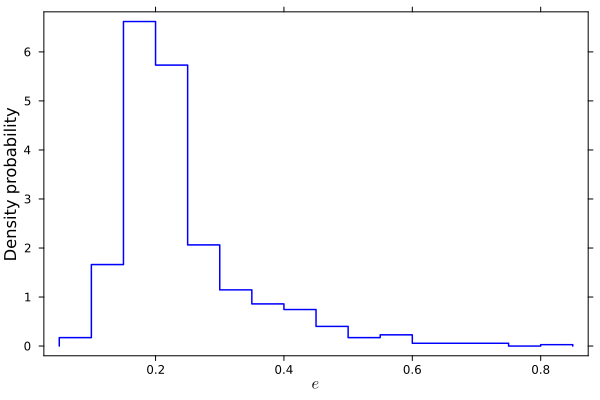

In [120]:
#eccentricity distribution for of deposit BHs in the eRO-QPE 2 band

using Plots
using StatsBase  

h = fit(Histogram, e_at_a_target; nbins=20)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

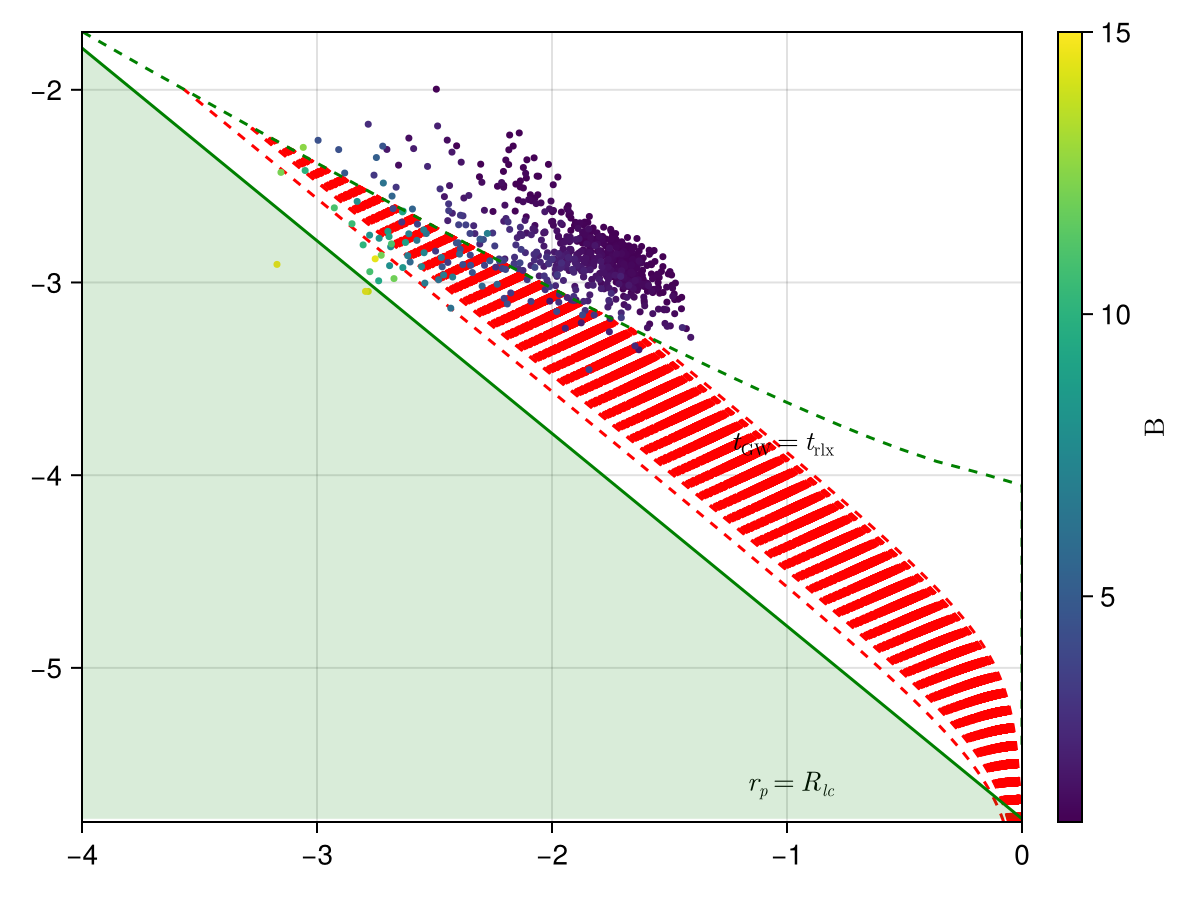

CairoMakie.Screen{IMAGE}


In [110]:
# Considering only outside points:

e_init_out = 1 .- 10 .^ x_outside_proj
a_init_out = 10 .^ y_outside_proj

e_at_a_target_out = Float64[]

fig = Figure()
ax_2 = Axis(fig[1,1])

first=true
for (e0, a0) in zip(e_init_out, a_init_out)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_out, e_at_log_a_p)

    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)
    if first
        lines!(ax_2, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5, label="Peters evolution")
        first = false
    else
        lines!(ax_2, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5)
    end
end

sc=scatter!(ax_2, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax_2, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax_2, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax_2, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
text!(ax_2, [maximum(log10.(-sqrt.(-R_eq.+1).+1)) - 0.8], [log10.(aux["rc"])[end] + 1.5], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax_2,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)

display(fig)

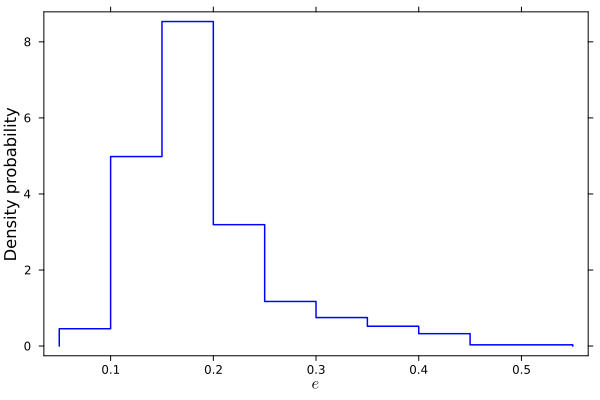

In [109]:
h = fit(Histogram, e_at_a_target_out; nbins=20)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

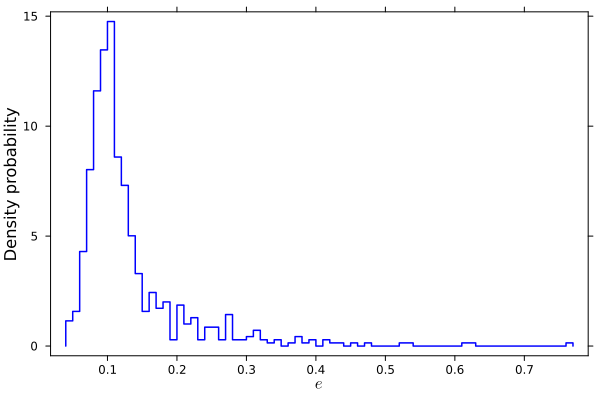

In [88]:
# Until the LISA band

a_target = 3.24e-6
e_at_a_target_2 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_2, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_2; nbins=100)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)


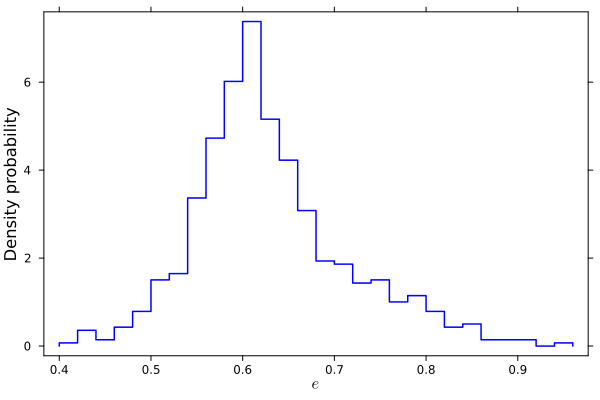

In [114]:
# until eRO-QPE3

a_target = 1.65e-5
e_at_a_target_3 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_3, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_3; nbins=30)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)


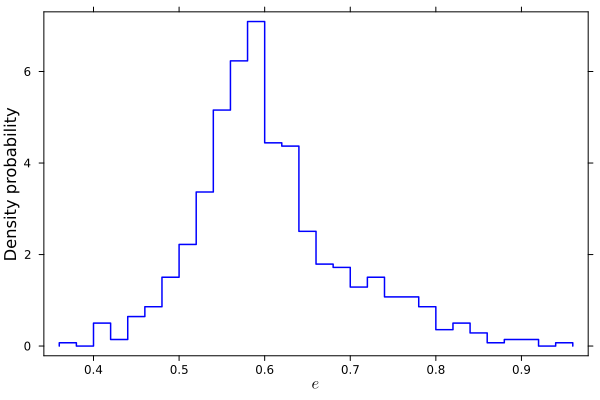

In [115]:
# until eRO-QPE4

a_target = 1.53e-5
e_at_a_target_4 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0

    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_4, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_4; nbins=30)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)


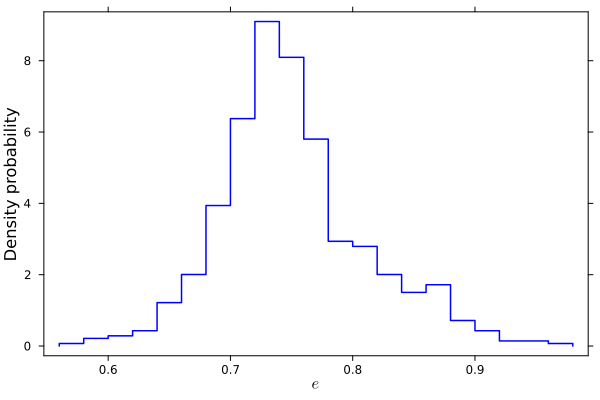

In [116]:
# Until eRO-QPE

a_target = 2.62e-5
e_at_a_target_5 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_5, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_5; nbins=30)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

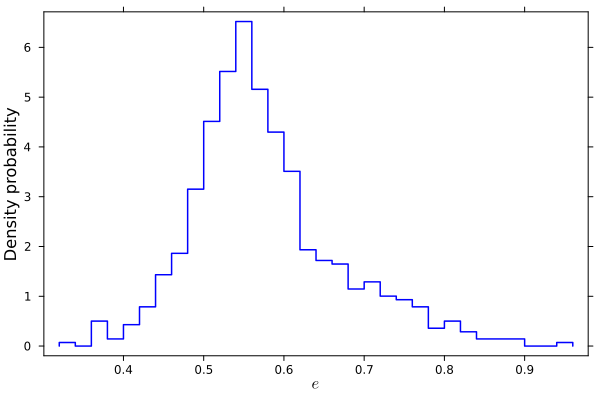

In [117]:
# until GSN 069

a_target = 1.39e-5
e_at_a_target_6 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_6, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_6; nbins=30)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

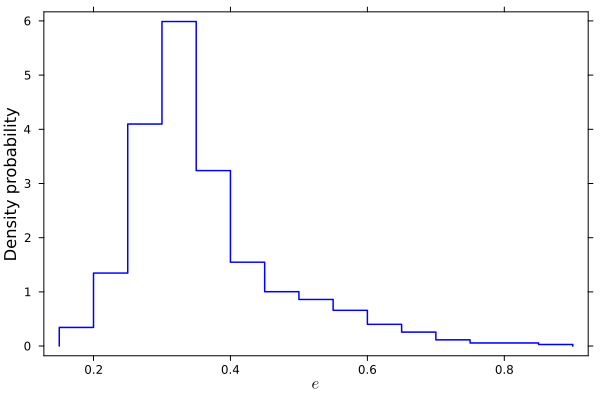

In [118]:
# Until  XMMSL1 J024916.6041244

a_target = 7.55e-6
e_at_a_target_7 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_7, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_7; nbins=30)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  e
)

In [ ]:
# Random evolution

rp_curve = linear_interpolation(x_vals, y_vals, extrapolation_bc=Line())  # r_p = R_lc
tgw_curve = linear_interpolation(log10.(-sqrt.(-R_eq .+ 1) .+ 1), log10.(aux["rc"]), extrapolation_bc=Line())  # t_GW = t_rlx

xs = log10.(-sampled_e .+ 1)
ys = log10.(sampled_a)

indices_arriba = [(i, x, y) for (i, (x, y)) in enumerate(zip(xs, ys)) if y > tgw_curve(x)]

Random.seed!(123)
puntos_extra = rand(indices_arriba, min(2, length(indices_arriba)))

indices_filtrados = [(i, x, y) for (i, (x, y)) in enumerate(zip(xs, ys))
    if rp_curve(x) <= y <= tgw_curve(x)]

puntos_ordenados = sort(indices_filtrados, by = p -> abs(p[3] - rp_curve(p[2])))
puntos_ordenados_final = [puntos_ordenados[i] for i in 1:5:length(puntos_ordenados)][1:min(3, length(puntos_ordenados) ÷ 5 + 1)]

e_peter = [x for (_, x, _) in puntos_ordenados_final] #this is actualli 1-e, whit los space
a_peter = [y for (_, _, y) in puntos_ordenados_final] #this is a, remenbeg the log scape
e_out = [x for (_, x, _) in puntos_extra]
a_out = [y for (_, _, y) in puntos_ordenados_final]

In [19]:
function interseccion_horizontal(loga)
    f(x) = tgw_curve(x) - loga
    x_left, x_right = -4.0, 0.0
    for _ in 1:100
        x_mid = (x_left + x_right) / 2
        if f(x_mid) * f(x_left) < 0
            x_right = x_mid
        else
            x_left = x_mid
        end
    end
    return (x_left + x_right) / 2
end


fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)")
sc=scatter!(ax, e_peter, a_peter, markersize = 8, color = :red)
sc2=scatter!(ax, e_out, a_out, markersize = 8, color = :blue)
sc3=scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color =(:black, 0.5) , markersize = 5, label="Initial points")
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
#text!(ax, [maximum(log10.(-sqrt.(-R_eq.+1).+1)) - 0.8], [log10.(aux["rc"])[end] + 0.1], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
#Colorbar(fig[1, 2], sc3, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)

function a_peters(e, c0)
    return c0 * (e.^(12/19)) ./ (1 .- e.^2) .* (1 .+ 121/304 .* e.^2).^(870/2299)
end

first=true 

for (x_log1me, y_loga) in zip(e_peter, a_peter)
    e0 = 1 - 10^x_log1me
    a0 = 10^y_loga
    
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.5, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)

    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)
    
    if first
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5, label="Peters evolution, inside GW")
        first = false
    else
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5)
    end
end

first=true 

for (x_log1me, y_loga) in zip(e_out, a_out)
    x_inter = interseccion_horizontal(y_loga)

    lines!(ax, [x_log1me, x_inter], [y_loga, y_loga], color=:blue, linestyle=:dot, linewidth=1.5)

    e0 = 1 - 10^x_inter
    a0 = 10^y_loga

    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0

    e_vals = range(0.5, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)

    if first
        lines!(ax, x_evol, y_evol, color=:blue, linestyle=:dash, linewidth=1.5, label="Evolution from relax domain")
        first = false
    else
        lines!(ax, x_evol, y_evol, color=:blue, linestyle=:dash, linewidth=1.5)
    end
end

log_a0 = -2.3
a0=10^log_a0

log1me_0 = interseccion_horizontal(log_a0)

e0 = 1 - 10^log1me_0

f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
c0 = a0 / f_e0

e_vals = range(0.5, stop=e0, length=200)
a_vals = a_peters(e_vals, c0)

x_evol = log10.(1 .- e_vals)
y_evol = log10.(a_vals)

lines!(ax, x_evol, y_evol, color=:black, linestyle=:dashdot, linewidth=2, label="Evolution from log(a)= -2.3")

scatter!(ax, [log1me_0], [log_a0], color=:black, markersize=8)

leg=axislegend(ax, position = :lb)
display(fig)
save("Random evolutions.pdf", fig)

LoadError: DimensionMismatch: arrays could not be broadcast to a common size: a has axes Base.OneTo(2) and b has axes Base.OneTo(3)

In [20]:
#Extracting som eccentricities 

const C = 2.88e-8
M = 4e6
resultado = C * (M / 1)^(1/3) #esta es la ecuacion de la 

log_a_target = log10(resultado)

function obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    log_a_vals = log10.(a_vals)
    if minimum(log_a_vals) > log_a_target
        return missing 
    end
    interp_e = linear_interpolation(log_a_vals, e_vals, extrapolation_bc=Line())
    return interp_e(log_a_target)
end

for (i, (x_log1me, y_loga)) in enumerate(zip(e_peter, a_peter))
    e0 = 1 - 10^x_log1me
    a0 = 10^y_loga
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    e_vals = range(0.5, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    println("Point inside the GW $i → e = $( @sprintf("%.4f", e_at_log_a) )")
end


for (i, (x_log1me, y_loga)) in enumerate(zip(e_out, a_out))
    x_inter = interseccion_horizontal(y_loga)
    e0 = 1 - 10^x_inter
    a0 = 10^y_loga
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    e_vals = range(0.1, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    println("Point outside GW (relax dominated) $i → e = $( @sprintf("%.4f", e_at_log_a) )")
end

log_a0 = -2.3
a0 = 10^log_a0
log1me_0 = interseccion_horizontal(log_a0)
e0 = 1 - 10^log1me_0
f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
c0 = a0 / f_e0
e_vals = range(0.01, stop=e0, length=200)
a_vals = a_peters(e_vals, c0)
e_at_log_a = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
println("Point outside GW at log10(a) = -2.3 → e = $( @sprintf("%.4f", e_at_log_a) )")

LoadError: UndefVarError: `a_peters` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [23]:
#check how deep can a binary goes, if 

r_lc = 8 * G *  (4.3e6 * Msun)  / c^2 * 3.24e-17
r_p = params["rlc"][2]/17
print(r_p)

1.6512100168731475e-6

In [24]:
r_lc #Beta until 15 makes sense

1.6462756466012758e-6

In [47]:
# Determinate the EMRIs rate:
Rate_emris= length(sampled_e)/((t2-t1)*10e9) #in Gyr-1


1.018e-7

In [120]:
t_unique = sort(unique(EMRIs_time))
t_unique2 = sort(unique(EMRIs_time))
cm = countmap(EMRIs_time)
counts = [cm[t] for t in t_unique]
push!(t_unique2, t2) 
dt = diff(t_unique2)  

lambda_interval = counts ./ dt
lambda_interval_yr= lambda_interval/10e9

# Graficar como step (cada intervalo constante)
fig = Figure()
ax = Axis(fig[1,1],
    xlabel = L"\mathrm{t}\;[\,\mathrm{Gyr}\,]",
    ylabel = L"\mathrm{EMRIs}\;[\mathrm{yr}^{-1}]"
)
CairoMakie.lines!(ax, t_unique, lambda_interval_yr)
CairoMakie.scatter!(ax, t_unique, lambda_interval_yr, markersize=10)
save("Rates_per_time.pdf", fig)

CairoMakie.Screen{PDF}
